# 02 - Padded Linear Convolution, PGD, and FISTA

The circular convolution model is mathematically convenient, but real sensors do not wrap light around image boundaries. In this notebook we move closer to the DiffuserCam tutorial convention:

$$ b = A x + n $$

where `A` means: pad the scene, convolve with a padded PSF by FFT, and crop the sensor-sized measurement.

## Setup

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
from PIL import Image

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'diffusercam_sim').exists():
            return candidate
    raise RuntimeError('Could not find project root containing src/diffusercam_sim')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from diffusercam_sim import (
    PaddedLinearConvolution,
    add_gaussian_noise,
    fista,
    make_diffuser_like_psf,
    make_synthetic_scene,
    projected_gradient_descent,
)
from diffusercam_sim.viz import save_convergence_plot, save_montage

RESULT_DIR = PROJECT_ROOT / 'results' / 'notebooks' / '02_padded_linear_pgd_fista'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('E:/RIT/Spring2026/ComputationalImaging/DiffuserCam2026')

## Build the Forward Operator

The operator object stores the padding/cropping geometry, the padded PSF, the FFT transfer function, and the adjoint operator. This is cleaner than scattering FFT details through the notebook.

In [2]:
image_size = 256
scene = make_synthetic_scene(image_size)
psf = make_diffuser_like_psf(image_size)
operator = PaddedLinearConvolution(psf)

{
    'image_shape': operator.image_shape,
    'padded_shape': operator.padded_shape,
    'lipschitz_bound': operator.lipschitz_bound,
}

{'image_shape': (256, 256),
 'padded_shape': (512, 512),
 'lipschitz_bound': 0.9999999999999993}

## Simulate a Measurement

The measurement is a cropped linear convolution plus Gaussian noise. This is already closer to a physical sensor than the circular model in Notebook 01.

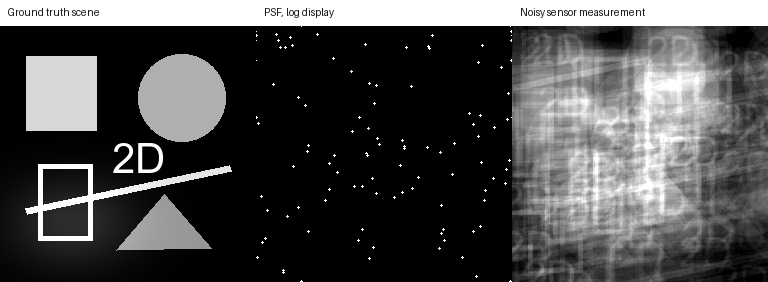

In [3]:
snr_db = 35.0
clean_measurement = operator.forward(scene)
measurement, noise_sigma = add_gaussian_noise(clean_measurement, snr_db)

save_montage(
    [
        ('Ground truth scene', scene),
        ('PSF, log display', psf),
        ('Noisy sensor measurement', measurement),
    ],
    RESULT_DIR / 'forward_model.png',
    columns=3,
)
Image.open(RESULT_DIR / 'forward_model.png')

## Adjoint Check

For iterative reconstruction, the gradient is:

$$ \nabla f(x) = A^H(Ax - b) $$

That only works if `A^H` is the true adjoint. We verify:

$$ \langle Ax, y \rangle = \langle x, A^H y \rangle $$

In [4]:
adjoint_error = operator.adjoint_inner_product_error()
adjoint_error

3.013635081837792e-15

## Projected Gradient Descent

We solve a nonnegative least-squares problem:

$$ \min_x \frac{1}{2}\|Ax-b\|_2^2 \quad \text{subject to } x \ge 0 $$

The update is:

$$ x_{k+1} = \max(x_k - \alpha A^H(Ax_k-b), 0) $$

In [6]:
iterations = 80
record_every = 5

pgd_result = projected_gradient_descent(
    operator=operator,
    measurement=measurement,
    iterations=iterations,
    truth=scene,
    record_every=record_every,
)

pgd_result.history[-1]

IterationRecord(iteration=80, objective=2.3228162792765246, relative_residual_l2=0.05578772092904244, psnr_db=14.51627108061994, ssim=0.3353435165191749)

## FISTA

FISTA uses the same gradient and nonnegativity projection, but adds a momentum point. This often reaches a useful reconstruction in fewer iterations.

In [7]:
fista_result = fista(
    operator=operator,
    measurement=measurement,
    iterations=iterations,
    truth=scene,
    record_every=record_every,
)

fista_result.history[-1]

IterationRecord(iteration=80, objective=0.10854378375807752, relative_residual_l2=0.012059621226992516, psnr_db=19.328759590621708, ssim=0.4829755004536874)

## Compare Reconstructions

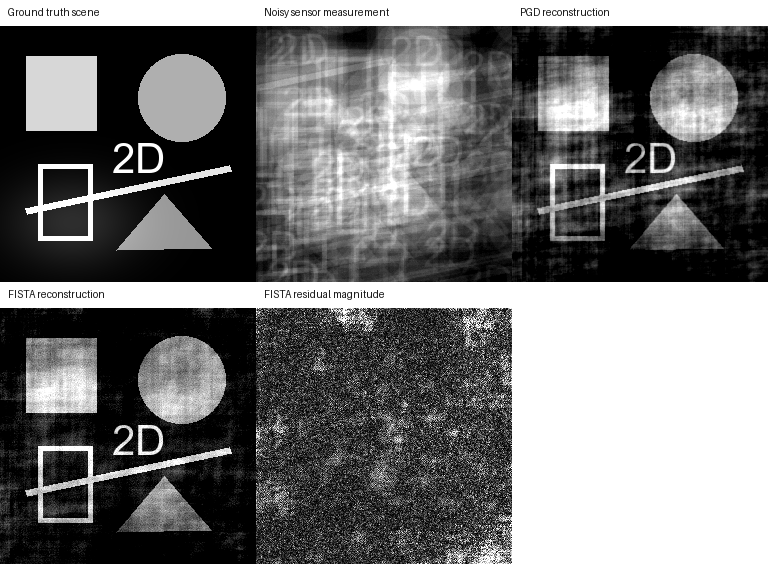

In [8]:
fista_predicted = operator.forward_padded(fista_result.padded_estimate)
fista_residual = fista_predicted - measurement

save_montage(
    [
        ('Ground truth scene', scene),
        ('Noisy sensor measurement', measurement),
        ('PGD reconstruction', pgd_result.reconstruction),
        ('FISTA reconstruction', fista_result.reconstruction),
        ('FISTA residual magnitude', np.abs(fista_residual)),
    ],
    RESULT_DIR / 'reconstruction_montage.png',
    columns=3,
)
Image.open(RESULT_DIR / 'reconstruction_montage.png')

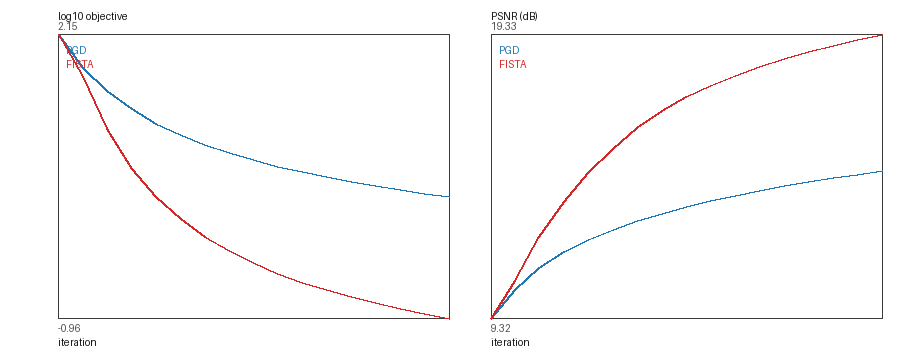

In [9]:
save_convergence_plot(
    [('PGD', pgd_result.history), ('FISTA', fista_result.history)],
    RESULT_DIR / 'convergence.png',
)
Image.open(RESULT_DIR / 'convergence.png')

In [10]:
summary = {
    'model': 'padded linear convolution with centered sensor crop',
    'image_shape': operator.image_shape,
    'padded_shape': operator.padded_shape,
    'snr_db': snr_db,
    'noise_sigma': noise_sigma,
    'adjoint_error': adjoint_error,
    'pgd_final': pgd_result.history[-1].__dict__,
    'fista_final': fista_result.history[-1].__dict__,
}
print(json.dumps(summary, indent=2))

{
  "model": "padded linear convolution with centered sensor crop",
  "image_shape": [
    256,
    256
  ],
  "padded_shape": [
    512,
    512
  ],
  "snr_db": 35.0,
  "noise_sigma": 0.0026835363748452055,
  "adjoint_error": 3.013635081837792e-15,
  "pgd_final": {
    "iteration": 80,
    "objective": 2.3228162792765246,
    "relative_residual_l2": 0.05578772092904244,
    "psnr_db": 14.51627108061994,
    "ssim": 0.3353435165191749
  },
  "fista_final": {
    "iteration": 80,
    "objective": 0.10854378375807752,
    "relative_residual_l2": 0.012059621226992516,
    "psnr_db": 19.328759590621708,
    "ssim": 0.4829755004536874
  }
}


## What to Notice

- The forward operator is now more realistic because it avoids wrap-around artifacts.
- The adjoint check is not cosmetic; it validates the gradient used by PGD and FISTA.
- Nonnegativity is a physical prior: intensity cannot be negative.
- FISTA should usually beat PGD at the same iteration count because momentum accelerates convergence.

Next step: add an explicit support constraint and compare it against the tutorial-style padded estimate.